In [186]:
# Data Handling & Computation
import pandas as pd   # For data manipulation (DataFrames)
import numpy as np    # For numerical operations

# Data Visualization
import matplotlib.pyplot as plt  # Basic plotting (line, bar, scatter plots)
import seaborn as sns           # Enhanced visualizations (heatmaps, distributions)

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Linear models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Ensemble models
from sklearn.tree import DecisionTreeRegressor  # Single decision tree model

# Model Evaluation & Preprocessing
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics
from sklearn.preprocessing import StandardScaler  # Feature scaling (normalization)
from sklearn.model_selection import train_test_split, GridSearchCV  # Splitting data & hyperparameter tuning
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Suppress warnings for cleaner output (use cautiously)
import warnings
warnings.filterwarnings('ignore')

In [188]:
# Load the dataset with error handling
try:
    df = pd.read_excel("boston_housing.xlsx")  # Read Excel
    print("Dataset loaded successfully!")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())  # Show a preview
    
except FileNotFoundError:
    print("Error: File 'boston_housing.xlsx' not found. Please check the file path.") # show a message when the file is not found or read
except Exception as e:  # Catch other potential errors
    print(f"An unexpected error occurred: {e}")

Dataset loaded successfully!

First 5 rows of the dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [190]:
if 'df' in locals():
    # Basic Info
    print("\n\033[1m=== Dataset Overview ===\033[0m")  # Bold header
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # show data in a better looking table
    print("\n\033[1mFirst 5 Rows:\033[0m")
    display(df.head().style.set_caption("Sample Data"))
    
    # Data Types
    print("\n\033[1mData Types:\033[0m")
    print(df.dtypes.to_string())  # Avoid truncation in long lists
    
    # Statistical Summary
    print("\n\033[1mSummary Statistics:\033[0m")
    display(df.describe(include='all').style.background_gradient(cmap='Blues'))  # Colorized stats
    
    # Missing Values Check
    print("\n\033[1mMissing Values:\033[0m")
    print(df.isnull().sum().to_string(name="Missing"))
else:
    print("Error: Dataset 'df' not loaded. Check data loading step.")


=== Dataset Overview ===
Shape: 506 rows, 14 columns

First 5 Rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006320,18.000000,2.310000,0,0.538000,6.575000,65.200000,4.090000,1,296,15.300000,396.900000,4.980000,24.000000
1,0.027310,0.000000,7.070000,0,0.469000,6.421000,78.900000,4.967100,2,242,17.800000,396.900000,9.140000,21.600000
2,0.027290,0.000000,7.070000,0,0.469000,7.185000,61.100000,4.967100,2,242,17.800000,392.830000,4.030000,34.700000
3,0.032370,0.000000,2.180000,0,0.458000,6.998000,45.800000,6.062200,3,222,18.700000,394.630000,2.940000,33.400000
4,0.069050,0.000000,2.180000,0,0.458000,7.147000,54.200000,6.062200,3,222,18.700000,396.900000,5.330000,36.200000



Data Types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64

Summary Statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000



Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0


In [192]:
def remove_outliers(df, column):
   
    Q1 = df[column].quantile(0.25)  # 25
    Q3 = df[column].quantile(0.75)  # 75
    IQR = Q3 - Q1  # Interquartile range
    
    # Calculate bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return filtered dataframe
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to all numeric features but the target
target = 'MEDV'
if target in df.columns:
    # numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_features = [col for col in numeric_cols if col != target]
    
    # Track rows
    initial_rows = df.shape[0]
    
    # Remove outliers
    for col in numeric_features:
        df = remove_outliers(df, col)
    
    # Report changes
    removed_rows = initial_rows - df.shape[0]
    print(f"\nOutlier removal:")
    print(f"- Removed {removed_rows} rows ({removed_rows/initial_rows:.1%} of data)")
    print(f"- New shape: {df.shape}")
else:
    print(f"Error: Target column '{target}' not found in dataframe")


Outlier removal:
- Removed 276 rows (54.5% of data)
- New shape: (230, 14)


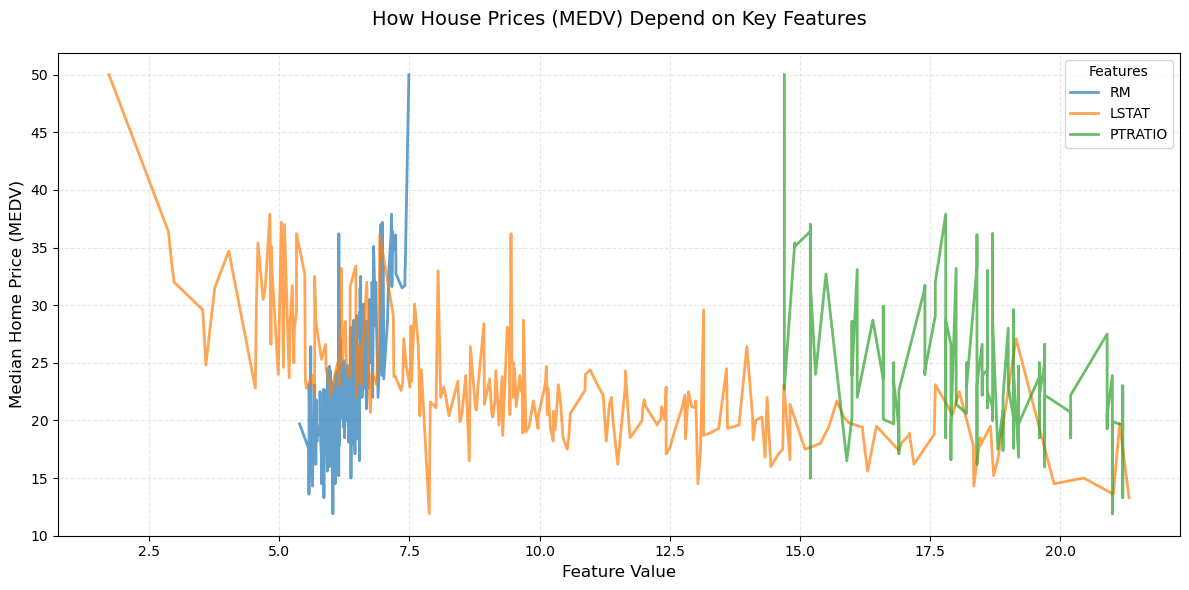

In [194]:
# Set up plot
plt.figure(figsize=(12, 6))

# Features
trend_features = ['RM', 'LSTAT', 'PTRATIO']

# Plot relationships
for feature in trend_features:
    # Sort values
    sorted_df = df.sort_values(by=feature)
    plt.plot(sorted_df[feature], sorted_df[target], 
             label=feature, alpha=0.7, linewidth=2)

# formatting
plt.title('How House Prices (MEDV) Depend on Key Features', fontsize=14, pad=20)
plt.xlabel('Feature Value', fontsize=12)
plt.ylabel('Median Home Price (MEDV)', fontsize=12)
plt.legend(title='Features', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

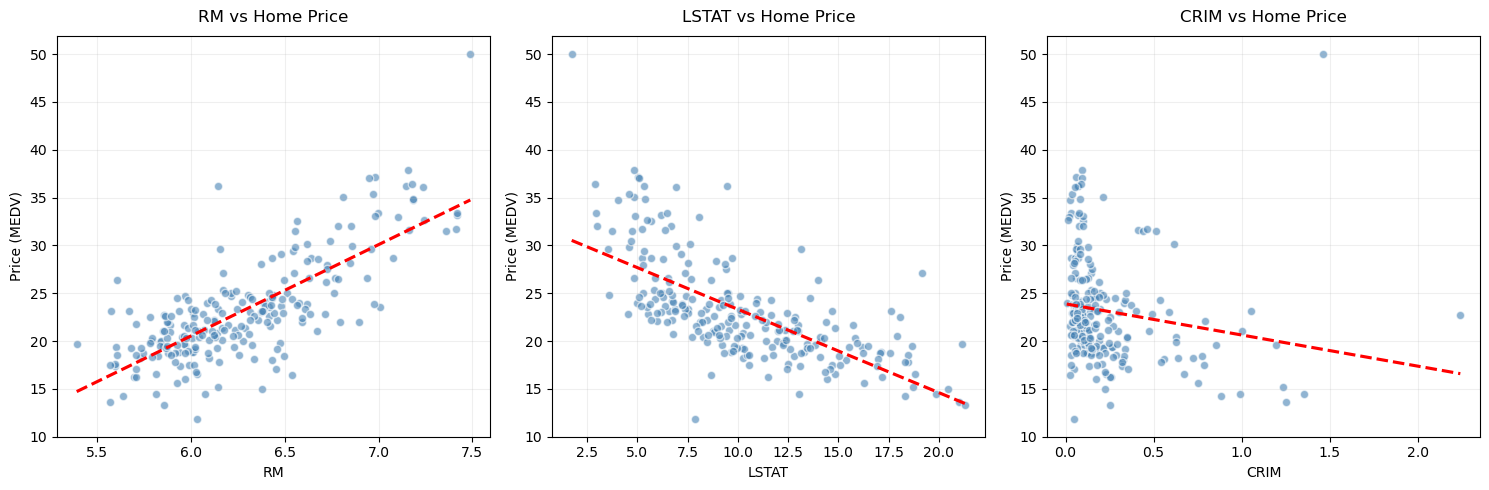

In [196]:
# Set up
plt.figure(figsize=(15, 5))

# features
scatter_features = ['RM', 'LSTAT', 'CRIM']  # Rooms, Poverty %, Crime Rate

# subplots
for i, feature in enumerate(scatter_features, 1):
    plt.subplot(1, 3, i)  # 1 row, 3 columns
    
    #  scatter plot
    plt.scatter(df[feature], df[target], alpha=0.6, c='steelblue', edgecolor='white')
    
    # trend line
    sns.regplot(x=feature, y=target, data=df, scatter=False, 
                color='red', ci=None, line_kws={'linestyle':'--'})
    
    # Formatting
    plt.title(f'{feature} vs Home Price', fontsize=12, pad=10)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Price (MEDV)', fontsize=10)
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

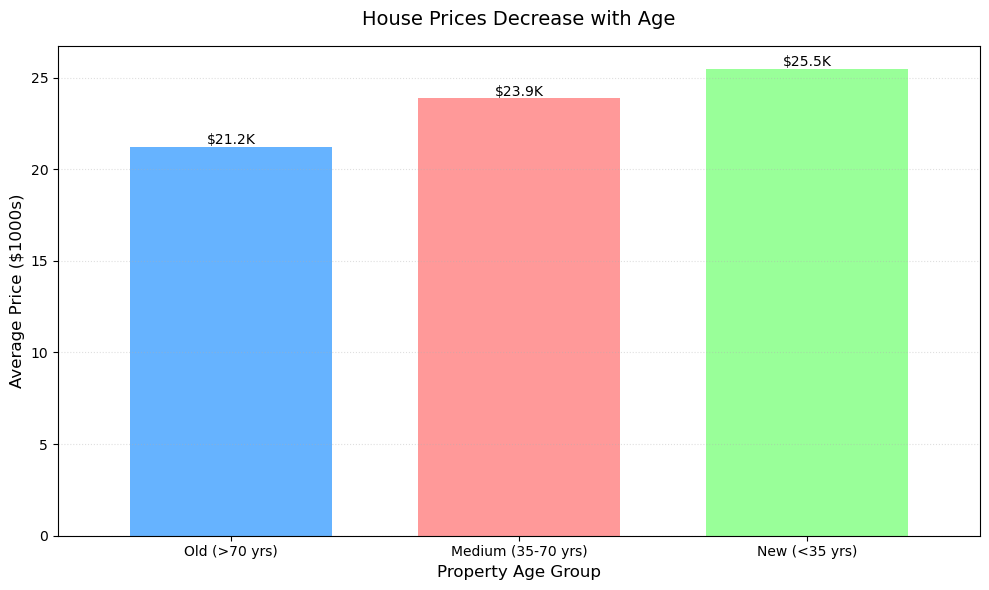

In [197]:
# age groups
df['AGE_GROUP'] = pd.cut(df['AGE'],
                        bins=[0, 35, 70, 100],
                        labels=['New (<35 yrs)', 'Medium (35-70 yrs)', 'Old (>70 yrs)'])

# plot
plt.figure(figsize=(10, 6))
ax = df.groupby('AGE_GROUP')['MEDV'].mean().sort_values().plot(
    kind='bar',
    color=['#66b3ff', '#ff9999', '#99ff99'],  # Modern pastel colors
    width=0.7
)

# Add value labels
for p in ax.patches:
    ax.annotate(f'${p.get_height():.1f}K', 
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center',
               xytext=(0, 5),
               textcoords='offset points',
               fontsize=10)

# Formatting
plt.title('House Prices Decrease with Age', fontsize=14, pad=15)
plt.xlabel('Property Age Group', fontsize=12)
plt.ylabel('Average Price ($1000s)', fontsize=12)
plt.xticks(rotation=0)  # Horizontal labels for cleaner look
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

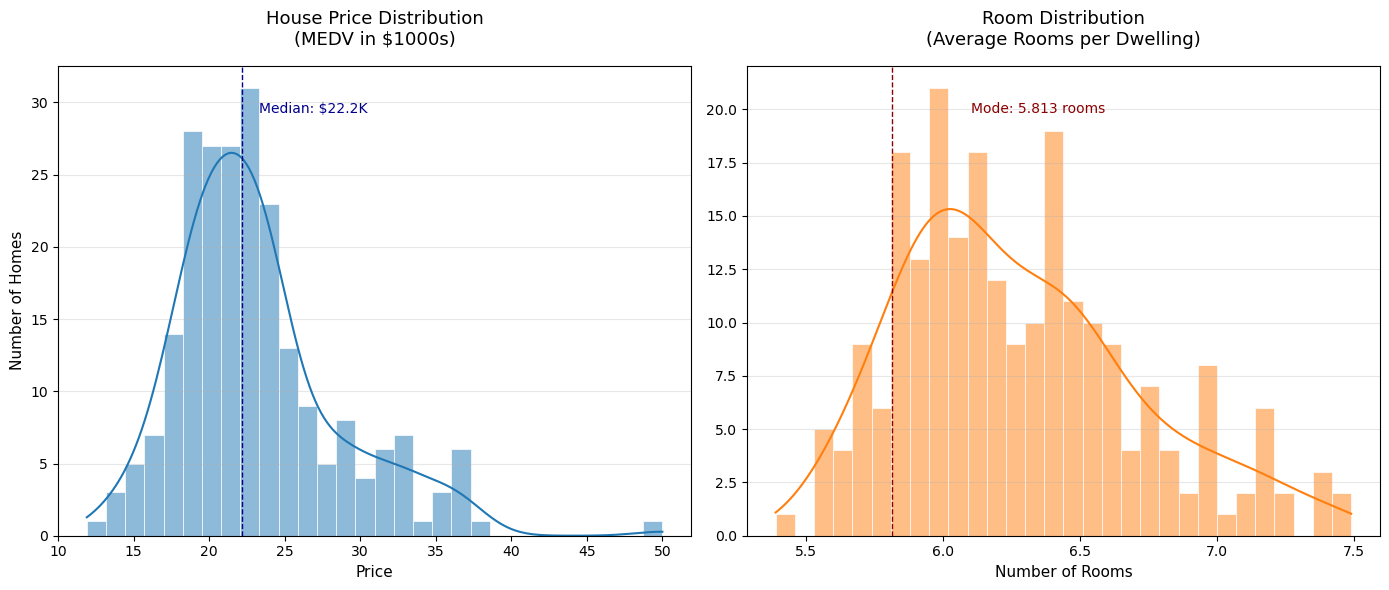

In [200]:
plt.figure(figsize=(14, 6))

# Price Distribution (Left)
plt.subplot(1, 2, 1)
sns.histplot(df['MEDV'], bins=30, color='#1f77b4', kde=True, 
             edgecolor='white', linewidth=0.5)
plt.title('House Price Distribution\n(MEDV in $1000s)', fontsize=13, pad=15)
plt.xlabel('Price', fontsize=11)
plt.ylabel('Number of Homes', fontsize=11)
plt.grid(axis='y', alpha=0.3)

# median line
median_price = df['MEDV'].median()
plt.axvline(median_price, color='darkblue', linestyle='--', linewidth=1)
plt.text(median_price*1.05, plt.ylim()[1]*0.9, 
         f'Median: ${median_price:.1f}K', color='darkblue')

# Room Distribution (Right)
plt.subplot(1, 2, 2)
sns.histplot(df['RM'], bins=30, color='#ff7f0e', kde=True,
             edgecolor='white', linewidth=0.5)
plt.title('Room Distribution\n(Average Rooms per Dwelling)', fontsize=13, pad=15)
plt.xlabel('Number of Rooms', fontsize=11)
plt.ylabel('')  # Avoid repeating y-label
plt.grid(axis='y', alpha=0.3)

# mode annotation
room_mode = df['RM'].mode()[0]
plt.axvline(room_mode, color='darkred', linestyle='--', linewidth=1)
plt.text(room_mode*1.05, plt.ylim()[1]*0.9, 
         f'Mode: {room_mode} rooms', color='darkred')

plt.tight_layout()
plt.show()

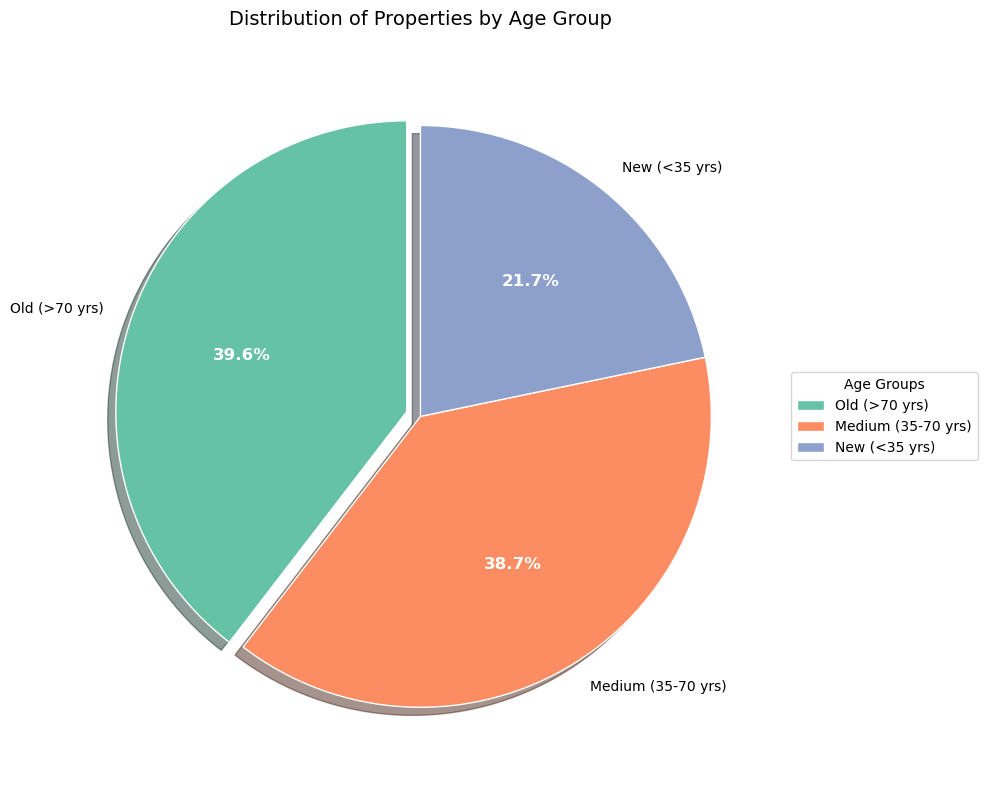

In [201]:
plt.figure(figsize=(10, 8))

# Prepare data
age_counts = df['AGE_GROUP'].value_counts()
colors = ['#66c2a5', '#fc8d62', '#8da0cb']  # Colorblind-friendly palette
explode = (0.05, 0, 0)  # Highlight the largest segment

# pie chart
wedges, texts, autotexts = plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# labels
plt.setp(autotexts, size=12, weight='bold', color='white')

# legend
plt.legend(
    wedges,
    age_counts.index,
    title="Age Groups",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# aspect ratio and title
plt.title('Distribution of Properties by Age Group', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

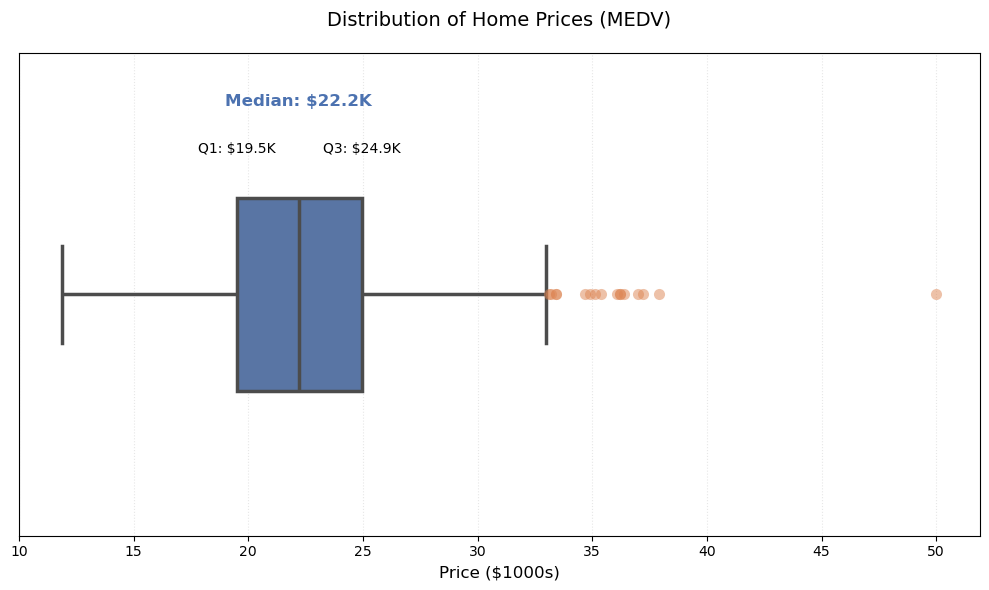

In [204]:
plt.figure(figsize=(10, 6))

# Create styled boxplot
box = sns.boxplot(
    x=df[target],
    color='#4C72B0',  # Professional blue
    width=0.4,
    linewidth=2.5,
    flierprops={
        'marker': 'o',
        'markersize': 8,
        'markerfacecolor': '#DD8452',  # Contrasting orange for outliers
        'markeredgecolor': 'none',
        'alpha': 0.5
    }
)

# Add annotations
median = df[target].median()
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)

plt.text(x=median, y=-0.4, 
         s=f'Median: ${median:.1f}K', 
         ha='center', va='center',
         fontsize=12, color='#4C72B0', weight='bold')

plt.text(x=q1, y=-0.3, 
         s=f'Q1: ${q1:.1f}K', 
         ha='center', va='center',
         fontsize=10)

plt.text(x=q3, y=-0.3, 
         s=f'Q3: ${q3:.1f}K', 
         ha='center', va='center',
         fontsize=10)

# Formatting
plt.title(f'Distribution of Home Prices ({target})', pad=20, fontsize=14)
plt.xlabel('Price ($1000s)', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle=':')

# Remove y-axis ticks for cleaner look
plt.yticks([])

plt.tight_layout()
plt.show()

TOP FEATURES AFFECTING HOME PRICES:
----------------------------------
RM              ↑ Increases price (r = 0.76)
ZN              ↑ Increases price (r = 0.32)
DIS             ↑ Increases price (r = 0.09)
RAD             ↑ Increases price (r = 0.07)
B               ↓ Decreases price (r = -0.02)
CRIM            ↓ Decreases price (r = -0.17)
TAX             ↓ Decreases price (r = -0.26)
AGE             ↓ Decreases price (r = -0.33)
NOX             ↓ Decreases price (r = -0.34)
INDUS           ↓ Decreases price (r = -0.35)


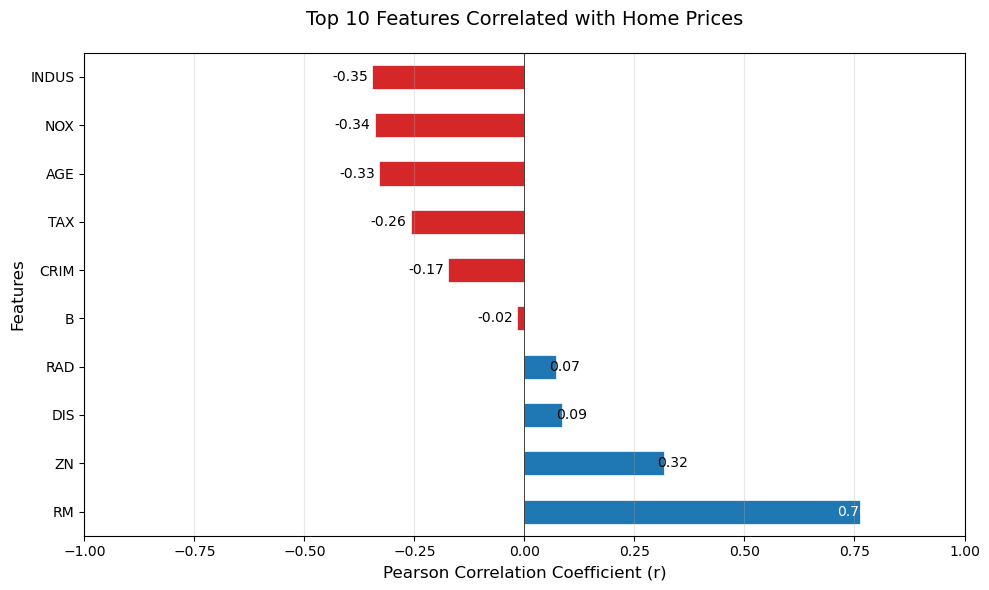

In [206]:
plt.figure(figsize=(12, 6))

# Calculate correlations
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# top MEDV correlations
target = 'MEDV'
top_corr = corr_matrix[target].sort_values(ascending=False).drop(target).head(10)

# Print results
print("TOP FEATURES AFFECTING HOME PRICES:")
print("----------------------------------")
for feature, corr_value in top_corr.items():
    direction = "↑ Increases" if corr_value > 0 else "↓ Decreases"
    print(f"{feature:15} {direction} price (r = {corr_value:.2f})")

# Visualisation
ax = top_corr.plot(kind='barh',  # Horizontal for better readability
                  color=['#1f77b4' if x > 0 else '#d62728' for x in top_corr],
                  edgecolor='white',
                  linewidth=0.5,
                  figsize=(10, 6))

# labels
for i, v in enumerate(top_corr):
    ax.text(v + (0.02 if v > 0 else -0.05), i, 
           f"{v:.2f}", 
           color='black' if abs(v) < 0.5 else 'white',
           ha='center' if abs(v) < 0.5 else 'right',
           va='center')

# Formatting
plt.title('Top 10 Features Correlated with Home Prices', pad=20, fontsize=14)
plt.xlabel('Pearson Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(-1, 1)  # Standard correlation range
plt.grid(axis='x', alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5)  # Zero reference line

plt.tight_layout()
plt.show()



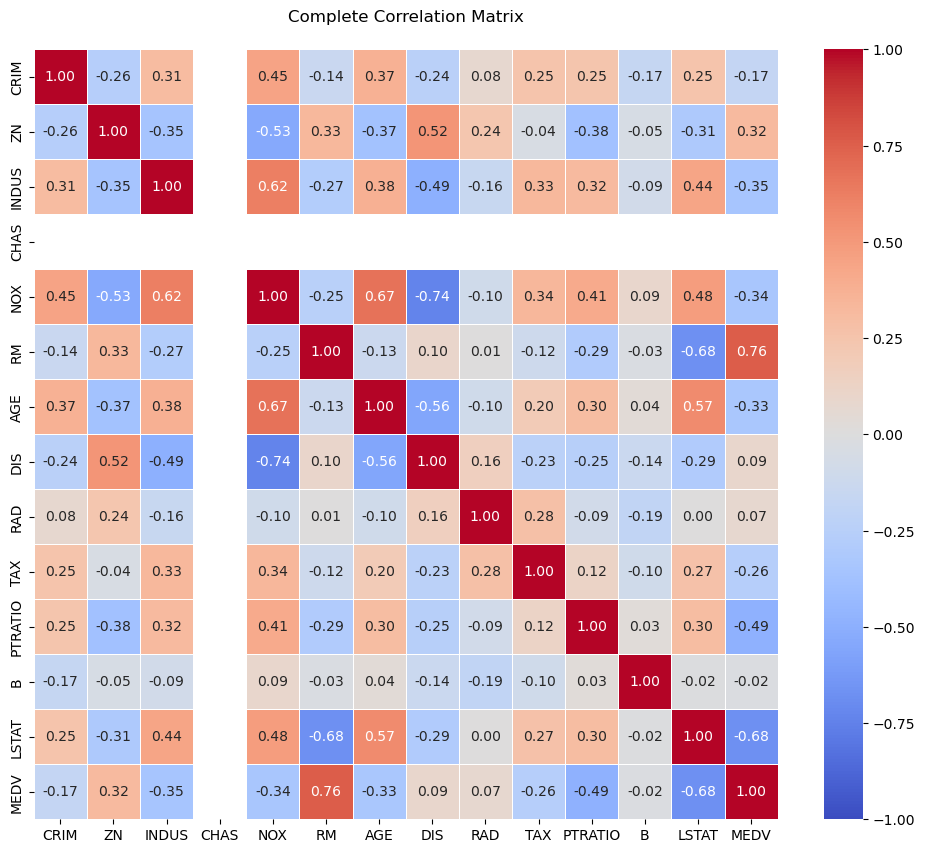

In [208]:
# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
           annot=True, 
           fmt=".2f", 
           cmap='coolwarm', 
           center=0,
           vmin=-1, vmax=1,
           linewidths=0.5)
plt.title('Complete Correlation Matrix', pad=20)
plt.show()

In [209]:
# Check if data exists and target is present
if 'df' in locals() and target in df.columns:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer

    # Create price bins for stratified split
    df['PRICE_BIN'] = pd.qcut(df[target], q=5)
    
    # Train-Test Split (stratified by price bins)
    X = df.drop(columns=[target, 'PRICE_BIN'])  # Features
    y = df[target]                             # Target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=df['PRICE_BIN']
    )
    
    # Handle Categorical Data
    categorical_cols = [col for col in X_train.columns 
                       if X_train[col].dtype == 'object' or 
                       X_train[col].nunique() < 10]
    
    # Create Processing Pipeline
    numeric_cols = [col for col in X_train.columns 
                   if col not in categorical_cols]
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ])
    
    # Apply Transformations
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    
    # Get feature names
    feature_names = (numeric_cols + 
                   list(preprocessor.named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))
    
    print("✔ Processing complete!")
    print(f"Training set: {X_train_processed.shape}")
    print(f"Test set: {X_test_processed.shape}")
    print(f"Sample features: {feature_names[:5]}...")
    
else:
    print("Error: Data not loaded or target column missing!")

✔ Processing complete!
Training set: (184, 23)
Test set: (46, 23)
Sample features: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM']...


In [212]:

# 2. LOAD AND PREPARE DATA
if 'df' in locals() and target in df.columns:
    # Feature engineering (do this BEFORE splitting)
    df['LSTAT'] = np.log1p(df['LSTAT'])  # Log-transform poverty rate
    df['CRIM'] = np.log1p(df['CRIM'])    # Log-transform crime rate
    
    # Split data
    X = df.drop(columns=[target])
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42
    )
    
    # PREPROCESSING
    # Identify feature types
    numeric_cols = X_train.select_dtypes(include=['number']).columns
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
    
    # Create preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
    
    # Fit and transform data
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)
    
    # TRAINING
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    
    # EVALUATION
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    print("\nModel Performance:")
    print(f"Training R²: {r2_score(y_train, train_pred):.4f}")
    print(f"Test R²: {r2_score(y_test, test_pred):.4f}")
    
    # Feature importance
    feature_names = list(numeric_cols) + \
                   list(preprocessor.named_transformers_['cat'] \
                       .get_feature_names_out(categorical_cols))
    
    print("\nTop 5 Features:")
    print(pd.Series(model.feature_importances_, index=feature_names)
          .sort_values(ascending=False).head(5))
    
else:
    print("Error: Data not loaded properly!")


Model Performance:
Training R²: 0.9823
Test R²: 0.9149

Top 5 Features:
PRICE_BIN_(26.6, 50.0]                   0.650237
PRICE_BIN_(11.899000000000001, 19.16]    0.112869
PRICE_BIN_(23.1, 26.6]                   0.065329
RM                                       0.046913
CRIM                                     0.024744
dtype: float64


In [216]:
# first 5 test predictions
sample_results = pd.DataFrame({
    'Actual Price': y_test[:5].values * 1000,  # Convert to full dollars
    'Predicted Price': test_pred[:5].round(0) * 1000
})

# dollar signs and commas
for col in sample_results.columns:
    sample_results[col] = sample_results[col].apply(lambda x: f"${int(x):,}")

# Print results
print("\nSample Predictions:")
for i, row in sample_results.iterrows():
    print(f"House {i+1}:")
    print(f"  Actual: {row['Actual Price']}")
    print(f"  Predicted: {row['Predicted Price']}\n")


Sample Predictions:
House 1:
  Actual: $21,800
  Predicted: $22,000

House 2:
  Actual: $22,900
  Predicted: $22,000

House 3:
  Actual: $15,000
  Predicted: $18,000

House 4:
  Actual: $23,800
  Predicted: $24,000

House 5:
  Actual: $23,100
  Predicted: $22,000

